# Parte 6 · Modelo final y demo de inferencia

**Visión por Computadora II · CEIA · FIUBA**

Esta notebook cierra el pipeline con un prototipo simple de inferencia.

- Carga el checkpoint final **EfficientNet-B0 con data augmentation**.
- Usa **CUDA automáticamente** si está disponible.
- Recibe una imagen individual y devuelve la clase predicha, confianza y top-3.
- Permite probar una imagen del test o una imagen externa.
- Mide la latencia local de inferencia como referencia para la demo.

No se vuelve a entrenar ningún modelo en esta etapa.


## 0. Configuración

Se reutilizan el split, las clases y el preprocesamiento definidos en las notebooks anteriores.  
El modelo final elegido es `effb0_aug`, porque combina alto desempeño de validación con mejor robustez frente a perturbaciones en la notebook 04.


In [1]:
import os
import sys
import time
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from PIL import Image
from torchvision import models


import common
importlib.reload(common)
from common import *  # ROOT, DATA_DIR, DEVICE (CUDA si está disponible), etc.

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró PlantVillage en {DATA_DIR}. "
        "Ubicarlo en PlantVillage/ (raíz del repo) o definir PV_DATA_DIR."
    )

print("Carpeta del dataset:", DATA_DIR)


MODEL_NAME = "efficientnet_b0"
FINAL_RUN = "effb0_aug"
IMG_SIZE_FT = 160

df, classes = load_split()
test_df = df[df["split"] == "test"].reset_index(drop=True)

# Buscamos el checkpoint tanto en la ubicación actual del proyecto
# como en la ubicación usada en versiones anteriores.
ckpt_candidates = [
    ROOT / "cache" / "ckpt_full" / f"{FINAL_RUN}.pt",
    Path.home() / ".cache" / "vpc2" / "ckpt_full" / f"{FINAL_RUN}.pt",
]
CKPT_PATH = next((p for p in ckpt_candidates if p.exists()), None)

if CKPT_PATH is None:
    raise FileNotFoundError(
        "No se encontró el checkpoint effb0_aug.pt. "
        "Ejecutar primero la notebook 03 en modo full."
    )

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Checkpoint:", CKPT_PATH)
print(f"Clases: {len(classes)} | Test: {len(test_df):,} imágenes")


Carpeta del dataset: C:\Users\santi\OneDrive\Documentos\CEIA\repo_ceia\vision_por_computadora_2\plant-disease-detection\PlantVillage
Python: C:\Users\santi\.pyenv\pyenv-win\versions\3.14.2\python.exe
PyTorch: 2.13.0+cpu
Device: cpu
Checkpoint: C:\Users\santi\OneDrive\Documentos\CEIA\repo_ceia\vision_por_computadora_2\plant-disease-detection\cache\ckpt_full\effb0_aug.pt
Clases: 15 | Test: 2,949 imágenes


## 1. Carga del modelo final

Para la demo no hacen falta los pesos originales de ImageNet: se crea la arquitectura EfficientNet-B0 y se cargan directamente los pesos del checkpoint entrenado. Esto evita una descarga innecesaria.

La transformación de evaluación es la misma usada en el fine-tuning: `160×160`, conversión a `float32` y normalización de ImageNet.


In [2]:
# Arquitectura sin descargar pesos preentrenados:
# el checkpoint contiene todos los parámetros del modelo fine-tuneado.
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(classes),
)

state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state)
model = model.to(DEVICE).eval()

_, eval_tf_demo = make_transforms(IMG_SIZE_FT, augment=False)

print(f"Modelo cargado: {FINAL_RUN}")


Modelo cargado: effb0_aug


## 2. Función de inferencia

La función siguiente recibe una ruta de imagen y devuelve:

- clase predicha;
- confianza de la predicción;
- top-3 de clases;
- latencia de una inferencia.

La confianza corresponde a la probabilidad `softmax` del modelo. No debe interpretarse como una certeza clínica o agronómica.


In [3]:
def pretty_label(label):
    return " ".join(
        label.replace("___", " - ")
             .replace("__", " ")
             .replace("_", " ")
             .split()
    )


def predict_image(image_path, topk=3):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"No existe: {image_path}")

    image = Image.open(image_path).convert("RGB")
    x = eval_tf_demo(image).unsqueeze(0).to(DEVICE)

    # Sincronización para medir correctamente cuando se usa CUDA.
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()

    with torch.inference_mode():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    latency_ms = (time.perf_counter() - t0) * 1000

    k = min(topk, len(classes))
    top_probs, top_idx = probs.topk(k)

    top3 = pd.DataFrame({
        "clase": [pretty_label(classes[int(i)]) for i in top_idx.cpu()],
        "probabilidad": top_probs.cpu().numpy(),
    })

    pred_idx = int(top_idx[0].item())

    return {
        "image": image,
        "pred_idx": pred_idx,
        "pred_class": classes[pred_idx],
        "confidence": float(top_probs[0].item()),
        "top3": top3,
        "latency_ms": latency_ms,
    }


def show_prediction(image_path, true_class=None):
    result = predict_image(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].imshow(result["image"])
    axes[0].axis("off")
    title = (
        f"Predicción: {pretty_label(result['pred_class'])}\n"
        f"Confianza: {result['confidence']:.1%}"
    )
    if true_class is not None:
        title += f"\nReal: {pretty_label(true_class)}"
    axes[0].set_title(title)

    plot_df = result["top3"].iloc[::-1]
    axes[1].barh(plot_df["clase"], plot_df["probabilidad"])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probabilidad")
    axes[1].set_title("Top-3")
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(
        result["top3"].assign(
            probabilidad=lambda d: d["probabilidad"].map(lambda x: f"{x:.2%}")
        )
    )

    print(f"Latencia de inferencia: {result['latency_ms']:.2f} ms")

    return result


## 3. Demo con una imagen del conjunto de test

Esta prueba sirve como chequeo rápido de funcionamiento.  
Se toma una imagen de test con semilla fija y se muestra también su etiqueta real.


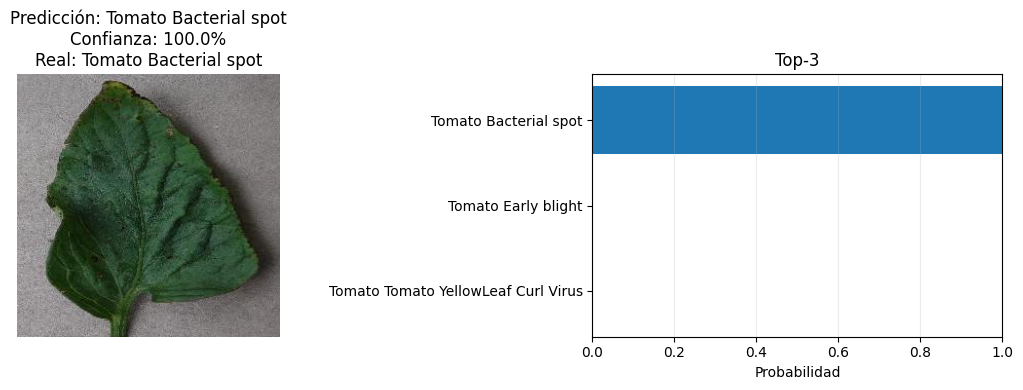

,clase,probabilidad
0,Tomato Bacterial spot,99.95%
1,Tomato Early blight,0.02%
2,Tomato Tomato YellowLeaf Curl Virus,0.01%


Latencia de inferencia: 37.07 ms


In [4]:
sample = test_df.sample(1, random_state=SEED).iloc[0]

sample_path = DATA_DIR / sample["relpath"]
sample_true = classes[int(sample["y"])]

_ = show_prediction(sample_path, true_class=sample_true)


## 4. Demo con una imagen externa

Para el video final conviene usar una imagen **fuera de PlantVillage**, por ejemplo una foto propia o una de la carpeta `data/real_world/`.

Solo hay que cambiar `IMAGE_PATH`. No es necesario conocer la etiqueta real para usar el prototipo.


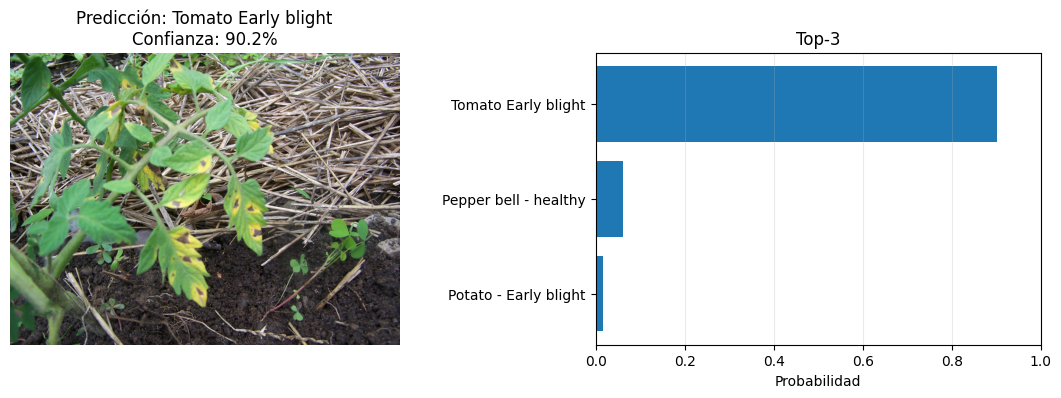

,clase,probabilidad
0,Tomato Early blight,90.24%
1,Pepper bell - healthy,6.22%
2,Potato - Early blight,1.59%


Latencia de inferencia: 19.94 ms


In [5]:
# Ejemplo:
# IMAGE_PATH = ROOT / "data" / "real_world" / "Tomato_Early_blight" / "foto_01.jpg"

# Por defecto: la primera imagen de PlantDoc descargada por la notebook 04, si existe.
ext_dir = ROOT / "data" / "real_world" / "Tomato_Early_blight"
ext_images = sorted(p for p in ext_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
IMAGE_PATH = ext_images[0] if ext_images else None


if IMAGE_PATH is None:
    print("Definir IMAGE_PATH con una imagen externa para ejecutar esta demo.")
else:
    _ = show_prediction(IMAGE_PATH)


## 5. Cierre

El prototipo final carga el checkpoint seleccionado y permite clasificar imágenes individuales con top-3 y confianza, utilizando GPU cuando está disponible.

Para la demostración grabada alcanza con:

1. mostrar brevemente el modelo y el dispositivo;
2. ejecutar una imagen externa;
3. explicar la clase predicha y el top-3;
4. mencionar que la notebook 04 evaluó la robustez ante cambios de iluminación, rotación, escala y blur, y el desempeño sobre imágenes externas de PlantDoc.

El sistema es un **prototipo académico** entrenado sobre PlantVillage. Su desempeño sobre imágenes de campo puede verse afectado por dominio, fondo, iluminación, encuadre y síntomas no representados en el dataset.
